<a href="https://colab.research.google.com/github/Dzapsana942/Devops/blob/main/Fashion_MNIST_projekt_opisany.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Rozpoznawanie elementów odzieży za pomocą sieci neuronowych na zbiorze Fashion-MNIST

Celem projektu jest zbudowanie i porównanie dwóch modeli uczenia maszynowego są służcych do rozpoznawania elementów odzieży. W projekcie wykorzystano zbiór Fashion-MNIST oraz porównano prostą sieć neuronową typu Dense z konwolucyjną siecią neuronową CNN.


## Import bibliotek

Na początku importowane są biblioteki potrzebne do pracy z danymi, tworzenia wykresów oraz budowania modeli sieci neuronowych w Keras.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense


## Wczytanie danych

Dane Fashion-MNIST są dostępne bezpośrednio w bibliotece Keras. Zbiór zawiera obrazy elementów odzieży podzielone na dane treningowe i testowe.


In [ ]:
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


## Sprawdzenie rozmiaru zbiorów

---



W tej części sprawdzany jest kształt danych. Obrazy mają rozmiar 28x28 pikseli, a etykiety określają klasę danego elementu odzieży.


In [ ]:
print("x_train:", x_train.shape)
print("y_train:", y_train.shape)

print("x_test:", x_test.shape)
print("y_test:", y_test.shape)

x_train: (60000, 28, 28)
y_train: (60000,)
x_test: (10000, 28, 28)
y_test: (10000,)


## Przykładowe obrazy ze zbioru

Poniżej wyświetlono kilka przykładowych obrazów ze zbioru treningowego. Dzięki temu można zobaczyć, jakie dane będą klasyfikowane przez modele.


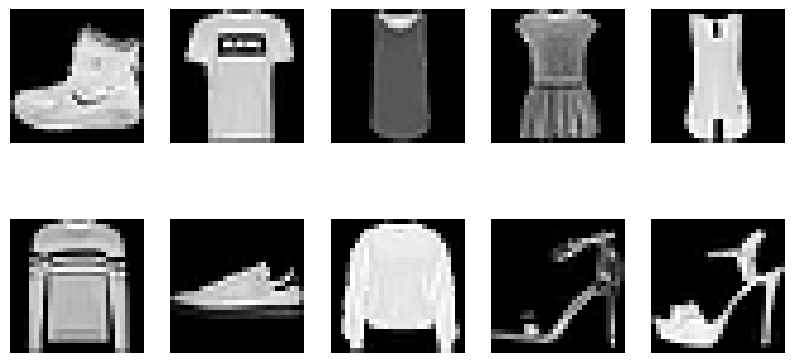

In [ ]:
plt.figure(figsize=(10,5))

for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i], cmap='gray')
    plt.axis('off')

plt.show()

## Przygotowanie danych

Wartości pikseli zostały znormalizowane z zakresu 0-255 do zakresu 0-1. Normalizacja ułatwia uczenie modelu i przyspiesza proces trenowania.


In [ ]:
x_train = x_train / 255.0
x_test = x_test / 255.0

## Model Dense

Pierwszym modelem jest prosta sieć neuronowa typu Dense. Obraz 28x28 pikseli jest najpierw spłaszczany do jednego wektora, a następnie przekazywany przez warstwy gęste. Ten model pełni rolę modelu bazowego, z którym porównany zostanie model CNN.


In [ ]:
model_dense = Sequential([
    Flatten(input_shape=(28,28)),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
model_dense.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model_dense.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history_dense = model_dense.fit(
    x_train,
    y_train,
    epochs=10,
    validation_split=0.2
)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 14s 7ms/step - accuracy: 0.8161 - loss: 0.5221 - val_accuracy: 0.8602 - val_loss: 0.4016
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.8621 - loss: 0.3787 - val_accuracy: 0.8651 - val_loss: 0.3661
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8760 - loss: 0.3388 - val_accuracy: 0.8650 - val_loss: 0.3679
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8819 - loss: 0.3161 - val_accuracy: 0.8611 - val_loss: 0.4015
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8892 - loss: 0.2963 - val_accuracy: 0.8700 - val_loss: 0.3680
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8943 - loss: 0.2838 - val_accuracy: 0.8818 - val_loss: 0.3290
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.8991 - loss: 0.2696 - val_accuracy: 0.8867 - val_loss: 0.3132
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9029 - loss: 0.2586 

In [ ]:
test_loss_dense, test_acc_dense = model_dense.evaluate(
    x_test,
    y_test
)

print("Test accuracy:", test_acc_dense)
print("Test loss:", test_loss_dense)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8748 - loss: 0.3739
Test accuracy: 0.8748000264167786
Test loss: 0.37393441796302795


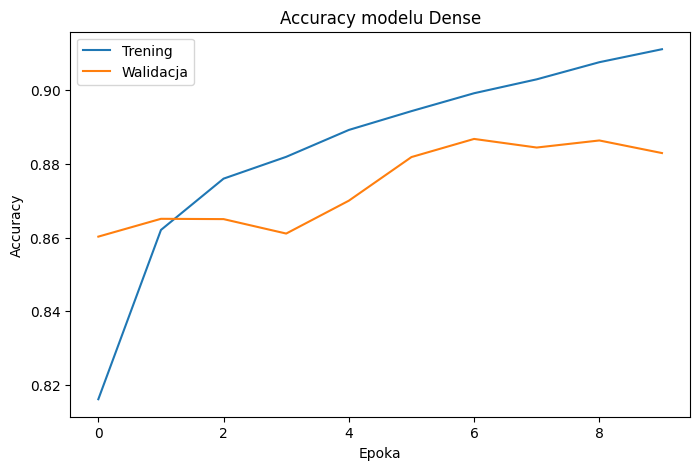

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(history_dense.history['accuracy'])
plt.plot(history_dense.history['val_accuracy'])

plt.title('Accuracy modelu Dense')
plt.xlabel('Epoka')
plt.ylabel('Accuracy')
plt.legend(['Trening', 'Walidacja'])

plt.show()

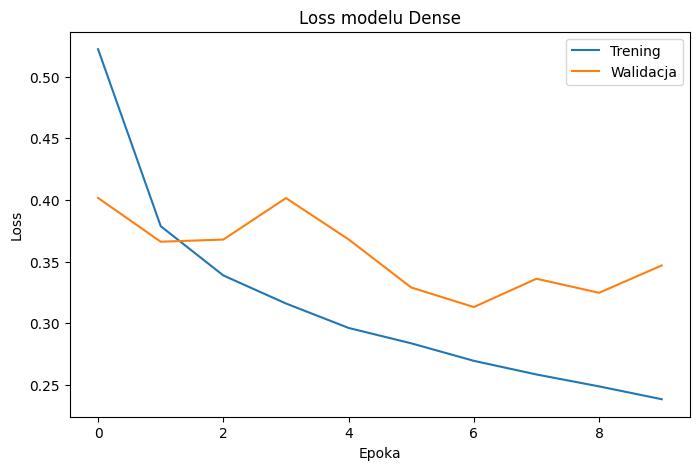

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(history_dense.history['loss'])
plt.plot(history_dense.history['val_loss'])

plt.title('Loss modelu Dense')
plt.xlabel('Epoka')
plt.ylabel('Loss')
plt.legend(['Trening', 'Walidacja'])

plt.show()

## Model CNN

Drugim modelem jest konwolucyjna sieć neuronowa CNN. Ten typ sieci jest szczególnie często stosowany do analizy obrazów, ponieważ potrafi wykrywać lokalne cechy, takie jak krawędzie, kontury i charakterystyczne fragmenty obiektów.


In [ ]:
x_train_cnn = x_train.reshape(-1, 28, 28, 1)
x_test_cnn = x_test.reshape(-1, 28, 28, 1)

print("x_train_cnn:", x_train_cnn.shape)
print("x_test_cnn:", x_test_cnn.shape)

x_train_cnn: (60000, 28, 28, 1)
x_test_cnn: (10000, 28, 28, 1)


## Budowa i trenowanie modelu CNN

Przed użyciem CNN dane muszą mieć dodatkowy wymiar kanału obrazu. Następnie tworzony jest model z warstwami konwolucyjnymi, warstwami pooling oraz warstwami Dense na końcu sieci.


In [ ]:
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Dropout

In [ ]:
model_cnn = Sequential([
    Input(shape=(28, 28, 1)),

    Conv2D(32, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),

    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),

    Flatten(),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(10, activation='softmax')
])

In [ ]:
model_cnn.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │       102,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 121,930 (476.29 KB)

 Trainable params: 121,930 (476.29 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model_cnn.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history_cnn = model_cnn.fit(
    x_train_cnn,
    y_train,
    epochs=10,
    validation_split=0.2
)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 52s 33ms/step - accuracy: 0.7779 - loss: 0.6125 - val_accuracy: 0.8568 - val_loss: 0.3875
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 79s 31ms/step - accuracy: 0.8523 - loss: 0.4060 - val_accuracy: 0.8798 - val_loss: 0.3270
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 83s 32ms/step - accuracy: 0.8717 - loss: 0.3540 - val_accuracy: 0.8907 - val_loss: 0.2976
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 49s 33ms/step - accuracy: 0.8830 - loss: 0.3198 - val_accuracy: 0.8936 - val_loss: 0.2927
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 81s 32ms/step - accuracy: 0.8920 - loss: 0.2967 - val_accuracy: 0.9027 - val_loss: 0.2687
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 48s 32ms/step - accuracy: 0.8997 - loss: 0.2726 - val_accuracy: 0.9030 - val_loss: 0.2596
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 46s 31ms/step - accuracy: 0.9047 - loss: 0.2563 - val_accuracy: 0.8960 - val_loss: 0.2803
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 83s 32ms/step - accuracy: 0.9124 -

In [ ]:
test_loss_cnn, test_acc_cnn = model_cnn.evaluate(
    x_test_cnn,
    y_test
)

print("Test accuracy CNN:", test_acc_cnn)
print("Test loss CNN:", test_loss_cnn)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9061 - loss: 0.2691
Test accuracy CNN: 0.9060999751091003
Test loss CNN: 0.26908615231513977


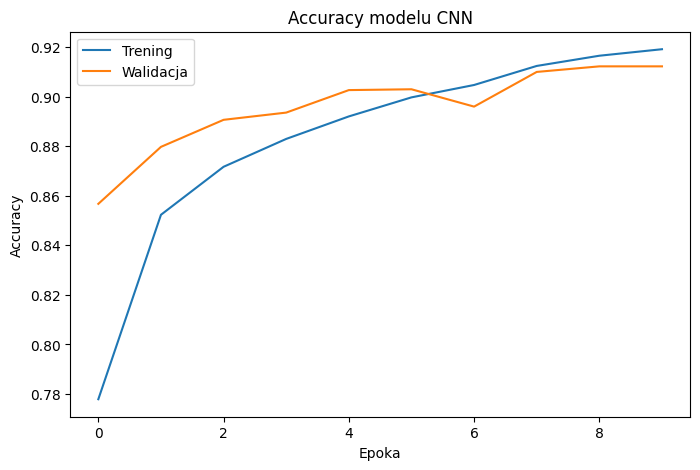

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(history_cnn.history['accuracy'])
plt.plot(history_cnn.history['val_accuracy'])

plt.title('Accuracy modelu CNN')
plt.xlabel('Epoka')
plt.ylabel('Accuracy')
plt.legend(['Trening', 'Walidacja'])

plt.show()

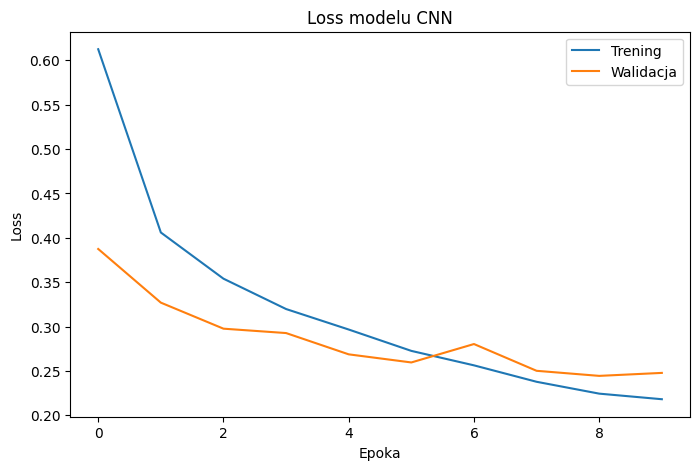

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(history_cnn.history['loss'])
plt.plot(history_cnn.history['val_loss'])

plt.title('Loss modelu CNN')
plt.xlabel('Epoka')
plt.ylabel('Loss')
plt.legend(['Trening', 'Walidacja'])

plt.show()

## Porównanie wyników modeli

W tej części porównano wyniki modelu Dense i modelu CNN na danych testowych. Porównywane są dwie wartości: accuracy, czyli skuteczność klasyfikacji, oraz loss, czyli wartość funkcji straty.


In [ ]:
import pandas as pd

wyniki = pd.DataFrame({
    'Model': ['Dense', 'CNN'],
    'Test accuracy': [test_acc_dense, test_acc_cnn],
    'Test loss': [test_loss_dense, test_loss_cnn]
})

wyniki

,Model,Test accuracy,Test loss
0,Dense,0.8748,0.373934
1,CNN,0.9061,0.269086


Model Dense uzyskał accuracy około 0.886, natomiast model CNN uzyska? accuracy około 0.904. Oznacza to, że model CNN lepiej poradził sobie z rozpoznawaniem elementów odzieży. Dodatkowo CNN osiągnął niższą wartość loss, co również wskazuje na lepsze dopasowanie modelu do danych testowych.


## Macierz pomyłek

Macierz pomyłek pokazuje, które klasy zostały rozpoznane poprawnie, a które model najczęściej mylił z innymi klasami. Jest to przydatne, ponieważ sama wartość accuracy nie pokazuje dokładnie, z którymi kategoriami model miał największy problem.


In [ ]:
class_names = [
    'T-shirt/top',
    'Trouser',
    'Pullover',
    'Dress',
    'Coat',
    'Sandal',
    'Shirt',
    'Sneaker',
    'Bag',
    'Ankle boot'
]

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step


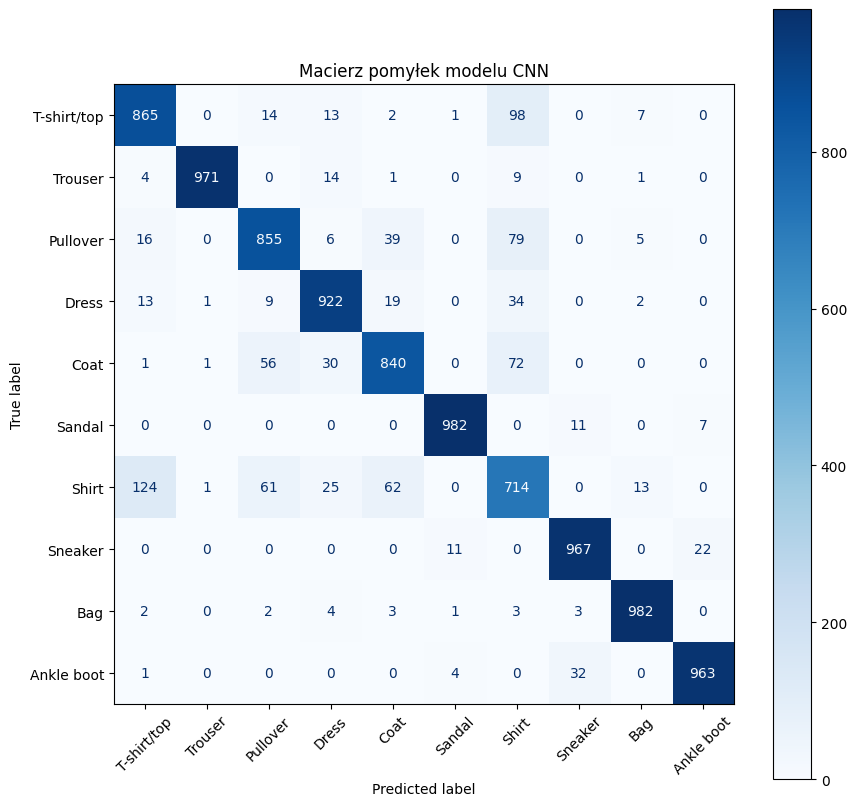

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred_cnn = model_cnn.predict(x_test_cnn)
y_pred_classes = np.argmax(y_pred_cnn, axis=1)

cm = confusion_matrix(y_test, y_pred_classes)

fig, ax = plt.subplots(figsize=(10, 10))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap='Blues', xticks_rotation=45, ax=ax)

plt.title('Macierz pomyłek modelu CNN')
plt.show()

## Przykłady błędnych klasyfikacji

Poniżej pokazano przykłady obrazów, które model CNN sklasyfikował niepoprawnie. Nad każdym obrazem znajduje się prawdziwa klasa oraz klasa przewidziana przez model.


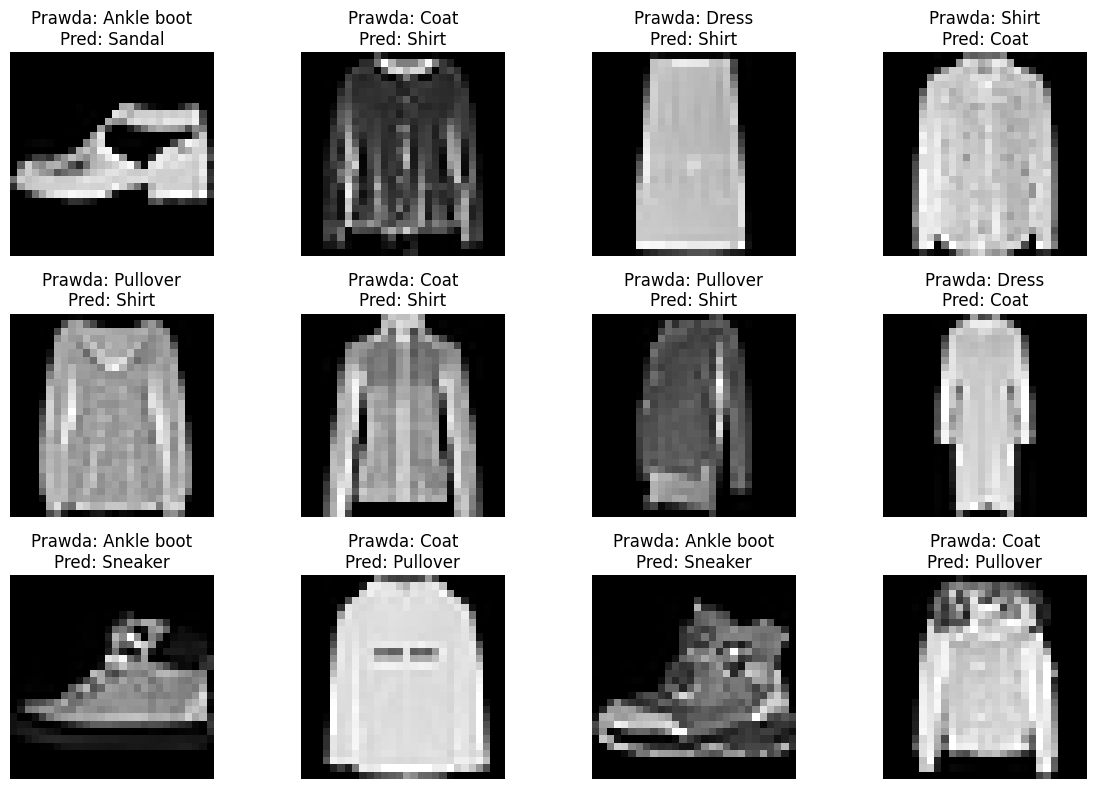

In [ ]:
wrong_indexes = np.where(y_pred_classes != y_test)[0]

plt.figure(figsize=(12, 8))

for i, idx in enumerate(wrong_indexes[:12]):
    plt.subplot(3, 4, i + 1)
    plt.imshow(x_test[idx], cmap='gray')
    plt.axis('off')
    plt.title(
        "Prawda: " + class_names[y_test[idx]] + "\nPred: " + class_names[y_pred_classes[idx]]
    )

plt.tight_layout()
plt.show()

## Wnioski

Celem projektu było porównanie skuteczności prostej sieci neuronowej Dense oraz konwolucyjnej sieci neuronowej CNN w zadaniu rozpoznawania elementów odzieży ze zbioru Fashion-MNIST.

Na podstawie otrzymanych wyników można stwierdzić, że model CNN osiągnął lepszy wynik niż model Dense. Accuracy modelu Dense wyniosło około 0.886, natomiast accuracy modelu CNN około 0.904. Oznacza to, że sieć konwolucyjna lepiej poradziła sobie z klasyfikacją obrazów.

Lepszy wynik CNN wynika z tego, że sieci konwolucyjne są lepiej przystosowane do analizy obrazów. Potrafił wykrywać lokalne cechy, takie jak krawędzie, kształty i fragmenty ubrań, podczas gdy model Dense analizuje obraz po spłaszczeniu go do jednego wektora.

Najczęstsze pomyłki pojawiały się między podobnymi kategoriami odzieży, na przykład koszulkę, koszulę, swetrem i płaszczem. Jest to zrozumiałe, ponieważ obrazy w zbiorze Fashion-MNIST są małe, czarno-białe i mają tylko 28x28 pikseli.

Projekt pokazuje, że dobór odpowiedniej architektury modelu ma duży wpływ na jakość klasyfikacji. W przypadku obrazów lepszym wyborem okazała się sieć CNN.
